# E-News Express — landing-page A/B test

Portfolio revision of a 2023 PGP Business Statistics project.
UT Austin McCombs / TEE + Great Learning. Certificate — not a UT degree.

## Takeaways

- 100 users, 50 old page (control) and 50 new page (treatment).
- Mean time on page: about **4.7 min old vs 6.6 min new**.
- Conversion: about **42% old vs 66% new** (24-point lift).
- Language is not the main driver of conversion or of time on the new page.
- Two-sample t-test (new > old): p ≈ 0.00014. Users spend more time on the new page.



### Context

E-News Express is an online news site that wants more subscribers. They built a new landing page and ran a small A/B test: 50 users on the old page (control), 50 on the new page (treatment).

### Objective

At a 5% significance level, answer:

1. Do users spend more time on the new page than on the old page?
2. Is conversion higher on the new page?
3. Does conversion depend on preferred language?
4. Is time on the *new* page the same across English, French, and Spanish?

### Columns

user_id, group (control / treatment), landing_page (old / new), time_spent_on_the_page, converted (yes / no), language_preferred.

## Import all the necessary libraries

In [254]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## Some code tools


In [255]:
#print each col name ... cut and paste help
def dfcols(df) :
  for col in df.columns:
      print(col)

In [256]:
#Scott Horning
# The function dflook takes a dataframe as a parameter and prints the shape and top, head and random rows

def dflook(df):
    print('shape...')
    print(f"{df.shape[0]} rows and {df.shape[1]} columns")
    print('head...')
    display(df.head(5))
    print('sample...')
    display(df.sample(5, replace=True))
    print('tail...')
    display(df.tail(5))

## Reading the Data into a DataFrame

In [257]:
from pathlib import Path

IN_COLAB = True   # False when the notebook sits in C:\code\... with abtest.csv beside it

if IN_COLAB:
    from google.colab import drive
    mount = Path("/content/drive")
    if not (mount.exists() and any(mount.iterdir())):
        drive.mount("/content/drive")
    MyDataFile = Path("/content/drive/MyDrive/Colab Notebooks/abtest.csv")
else:
    MyDataFile = Path("abtest.csv")

if not MyDataFile.exists():
    raise FileNotFoundError(MyDataFile)

print("Loading", MyDataFile)
df = pd.read_csv(MyDataFile)

Loading /content/drive/MyDrive/Colab Notebooks/abtest.csv


## Explore the dataset and extract insights using Exploratory Data Analysis (EDA)

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [258]:
# Peak at the first 5 records
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [259]:
# Peak at a random sample
df.sample(5, replace=True)

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
43,546453,treatment,new,7.16,yes,English
4,546459,treatment,new,4.75,yes,Spanish
78,546486,treatment,new,9.12,yes,French
68,546484,treatment,new,6.70,no,Spanish
15,546466,treatment,new,6.27,yes,Spanish


In [260]:
# Peak at the last 5 records
df.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [261]:
# Return a tuple representing the dimensionality of the DataFrame.
display(df.shape)
print("There are", df.shape[0], 'rows and', df.shape[1], "columns.")



(100, 6)

There are 100 rows and 6 columns.


In [262]:
#Generate a list of column names
dfcols(df)

user_id
group
landing_page
time_spent_on_the_page
converted
language_preferred


In [263]:
#The index (row labels) of the DataFrame
df.index

RangeIndex(start=0, stop=100, step=1)

In [264]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [265]:
#Check the statistical summary of the data. What is the minimum, average, and maximum
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,100.0,NaN,NaN,NaN,546517.0,52.295779,546443.0,546467.75,546492.5,546567.25,546592.0
group,100,2,control,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
landing_page,100,2,old,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_spent_on_the_page,100.0,NaN,NaN,NaN,5.3778,2.378166,0.19,3.88,5.415,7.0225,10.71
converted,100,2,yes,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language_preferred,100,3,Spanish,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [266]:
#change the data type of user_id to string because it is a key
# user_id has low significance in this file but is more accuratly categoriesed as a string.
NewCol =  df['user_id'].astype(str)
df['user_id'] = NewCol

In [267]:
# Use info() to print a NEW concise summary of the DataFrame and user_id is indeed a string
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    object 
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), object(5)
memory usage: 4.8+ KB


In [268]:
#Check the statistical summary of the data. What is the minimum, average, and maximum
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,100,100,546592,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
group,100,2,control,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
landing_page,100,2,old,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_spent_on_the_page,100.0,NaN,NaN,NaN,5.3778,2.378166,0.19,3.88,5.415,7.0225,10.71
converted,100,2,yes,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language_preferred,100,3,Spanish,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [269]:
#Checking for missing values in the data
df.isnull().sum()

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


In [270]:
# Checking for duplicate entries in the data
df.duplicated().sum()

np.int64(0)

In [271]:
# Making a list of all categorical variables
from pandas.api.types import is_numeric_dtype
from pandas.api.types import is_string_dtype
cat_cols = [cols for cols in df.columns if is_string_dtype(df[cols])]
cat_cols

num_cols = [cols for cols in df.columns if is_numeric_dtype(df[cols])]
num_cols

['time_spent_on_the_page']

In [272]:
# Printing the count of unique categorical levels in each column
print("-" * 50)
for column in cat_cols:
    print('Column name is:',column)
    print("-" * 50)
    print(df[column].value_counts())
    print("-" * 50)

--------------------------------------------------
Column name is: user_id
--------------------------------------------------
user_id
546592    1
546468    1
546462    1
546567    1
546459    1
         ..
546446    1
546544    1
546472    1
546481    1
546483    1
Name: count, Length: 100, dtype: int64
--------------------------------------------------
Column name is: group
--------------------------------------------------
group
control      50
treatment    50
Name: count, dtype: int64
--------------------------------------------------
Column name is: landing_page
--------------------------------------------------
landing_page
old    50
new    50
Name: count, dtype: int64
--------------------------------------------------
Column name is: converted
--------------------------------------------------
converted
yes    54
no     46
Name: count, dtype: int64
--------------------------------------------------
Column name is: language_preferred
-----------------------------------------------

In [273]:
# capture categorical counts.
no_of_rows = len(df.columns)


#  records for object/categorical data
cat_df = pd.DataFrame(index=np.arange(0, no_of_rows),  columns=('column_name', 'col_data_type' ,'values_count',  'unique_values_count' ))


# loop through all the columns and make count and distinct count entries
for ind, cols in enumerate(df.columns):
    # Count of unique values in the column
    col_unique_count = df[cols].nunique()
    cat_df.loc[ind] = [cols, df[cols].dtype, df[cols].count(), col_unique_count ]

#Filter out the numerics / Keep the catgoicals
cat_df =cat_df.loc[cat_df['col_data_type'] == 'object']
cat_df


,column_name,col_data_type,values_count,unique_values_count
0,user_id,object,100,100
1,group,object,100,2
2,landing_page,object,100,2
4,converted,object,100,2
5,language_preferred,object,100,3


In [274]:
# Get the list of numeric columns
num_cols = [cols for cols in df.columns if is_numeric_dtype(df[cols]) ]
num_cols

['time_spent_on_the_page']

In [275]:
# Use describe() to get column stats of numerics
numerics_df = df.describe().T.round(2)
numerics_df

,count,mean,std,min,25%,50%,75%,max
time_spent_on_the_page,100.0,5.38,2.38,0.19,3.88,5.42,7.02,10.71


#### Observations by Scott Horning :

 * The data file name is named abtest.csv and contains entries testing an existing and a proposed new format website.

 * The shape of the data set is  100 records and 6 columns.

 * The data set has an index that starts at 0 it runs to 99 and it is a step one.

 * The initial summary of the data frame includes four object columns one float column and one integer column

 * the column is the integer column and that should be recast to object/string

 * There are no missing values in the data.

 * There are no duplicated records in the data.


### Univariate Analysis

Generate data profile graphs for numerical columns

1  of  1  completed    time_spent_on_the_page
fig_time_spent_on_the_page
Wrote /content/drive/MyDrive/Colab Notebooks/fig_time_spent_on_the_page


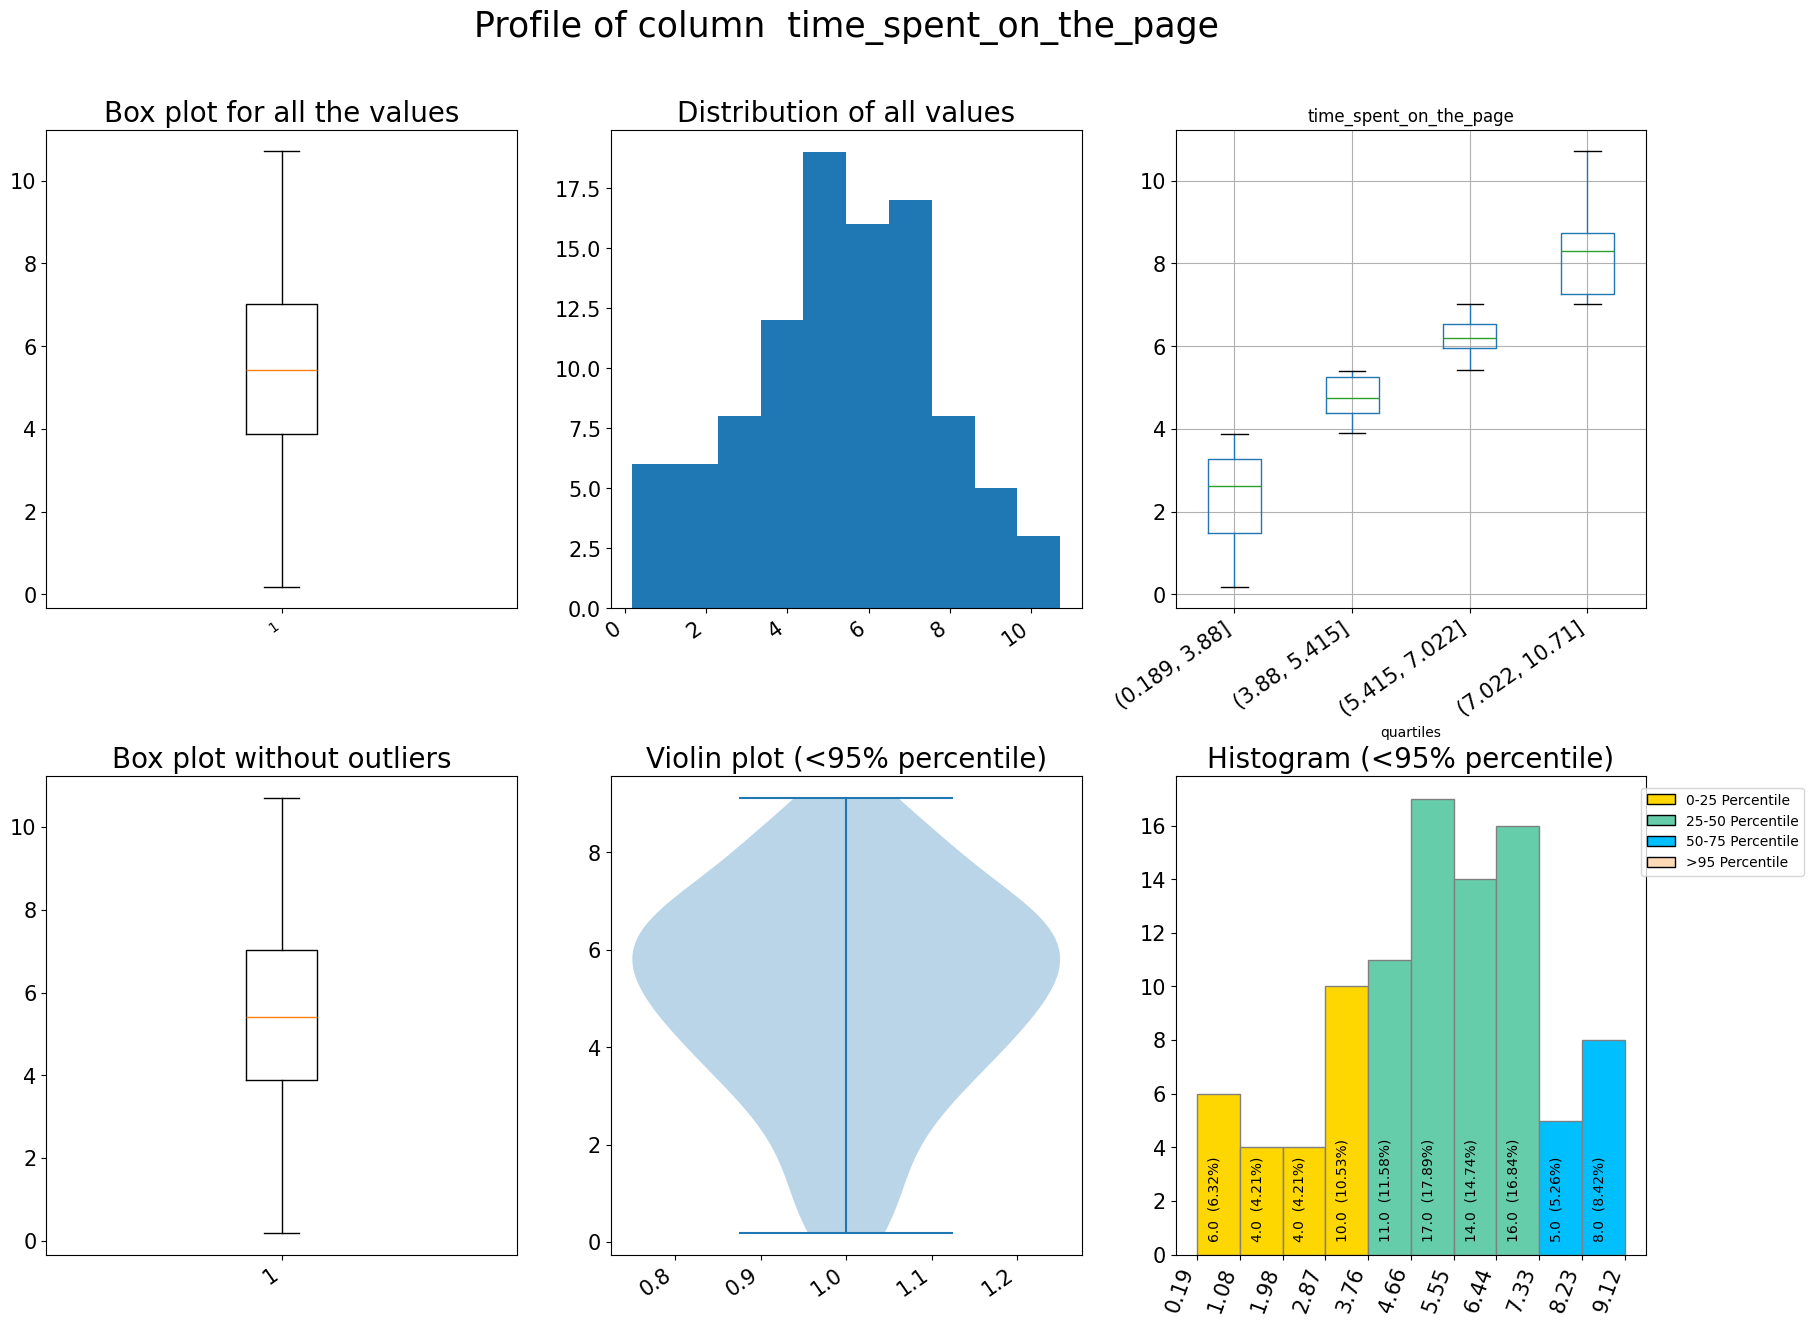

In [276]:
# Create  3X2 matrix of plots for numeric columns
from matplotlib.patches import Rectangle
from IPython.display import Image

# Get the list of numeric columns
num_cols = [cols for cols in df.columns if is_numeric_dtype(df[cols])]

# Varible for printing a band to separate output.
iter_len = len(num_cols)

# For each numeric column in the list
for x, col_name in enumerate(num_cols):
    print(x+1, " of ", iter_len, " completed   ",  col_name)

    # the column values without nulls or NA
    column_in_play = df[col_name].dropna()


    # Calculate the 95 percentile of the values
    q25 = np.percentile(column_in_play, 25)
    q75 = np.percentile(column_in_play, 75)
    q95 = np.percentile(column_in_play, 95)

    # Plot the graphs
    fig = plt.figure(figsize=(20,15))
    fig.suptitle("Profile of column  " + col_name, fontsize=25)  #Title for the whole figure
    plt.subplots_adjust(wspace=0.4, hspace=0.35)

    ax = fig.add_subplot(2,3,1)
    ax.set_title("Box plot for all the values", fontsize=20)
    plt.setp(ax.get_xticklabels(), ha="right", rotation=35)
    plt.setp(ax.get_yticklabels(), ha="right", fontsize=15)
    ax.boxplot(column_in_play)

    ax = fig.add_subplot(2,3,2)
    ax.set_title("Distribution of all values", fontsize=20)
    plt.setp(ax.get_xticklabels(), ha="right", rotation=35, fontsize=15)
    plt.setp(ax.get_yticklabels(), ha="right", fontsize=15)
    ax.hist(column_in_play)

    ax = fig.add_subplot(2,3,3)
    ax.set_title("Boxplot for quartiles (all values)", fontsize=20)
    if len(column_in_play.value_counts()) >= 4:
        df[u'quartiles'] = pd.qcut(
                        df[col_name],
                        4, duplicates='drop')
        df.boxplot(column= col_name, by=u'quartiles', ax = ax)
    plt.setp(ax.get_xticklabels(), ha="right", rotation=35, fontsize=15)
    plt.setp(ax.get_yticklabels(), ha="right", fontsize=15)

    ax = fig.add_subplot(2,3,4)
    ax.set_title("Box plot without outliers", fontsize=20)
    plt.setp(ax.get_xticklabels(), ha="right", rotation=35, fontsize=15)
    plt.setp(ax.get_yticklabels(), ha="right", fontsize=15)
    ax.boxplot(column_in_play, showfliers=False)

    ax = fig.add_subplot(2,3,5)
    ax.set_title("Violin plot (<95% percentile)", fontsize=20)
    plt.setp(ax.get_xticklabels(), ha="right", rotation=35, fontsize=15)
    plt.setp(ax.get_yticklabels(), ha="right", fontsize=15)
    ax.violinplot(column_in_play[column_in_play <= q95])


    #Histogram with bin ranges, counts and percentile color
    ax = fig.add_subplot(2,3,6)
    ax.set_title("Histogram (<95% percentile)", fontsize=20)
    plt.setp(ax.get_xticklabels(), ha="right", rotation=35, fontsize=15)
    plt.setp(ax.get_yticklabels(), ha="right", fontsize=15)

    # Take only the data less than 95 percentile
    data = column_in_play[column_in_play <= q95]

    # code the colors
    perc_25_colour = 'gold'
    perc_50_colour = 'mediumaquamarine'
    perc_75_colour = 'deepskyblue'
    perc_95_colour = 'peachpuff'

    counts, bins, patches = ax.hist(data, bins=10, facecolor=perc_50_colour, edgecolor='gray')

    # Set the ticks on edges of the bins.
    ax.set_xticks(bins.round(2))
    plt.xticks(rotation=70, fontsize=15)

    # Change the colors of bars at the edges
    for patch, leftside, rightside in zip(patches, bins[:-1], bins[1:]):
        if rightside < q25:
            patch.set_facecolor(perc_25_colour)
        elif leftside > q95:
            patch.set_facecolor(perc_95_colour)
        elif leftside > q75:
            patch.set_facecolor(perc_75_colour)

    #  display the count of data points and % at center of bar
    bin_x_centers = 0.5 * np.diff(bins) + bins[:-1]
    bin_y_centers = ax.get_yticks()[1] * 0.25

    # Display the the count of data points and % for each bar in histogram
    for i in range(len(bins)-1):
        bin_label = "{0:,}".format(counts[i]) + "  ({0:,.2f}%)".format((counts[i]/counts.sum())*100)
        plt.text(bin_x_centers[i], bin_y_centers, bin_label, rotation=90, rotation_mode='anchor')

    #create legend
    handles = [Rectangle((0,0),1,1,color=c,ec="k") for c in [perc_25_colour, perc_50_colour, perc_75_colour, perc_95_colour]]
    labels= ["0-25 Percentile","25-50 Percentile", "50-75 Percentile", ">95 Percentile"]
    plt.legend(handles, labels, bbox_to_anchor=(0.5, 0., 0.85, 0.99))

    #Title for the whole figure
    fig.suptitle("Profile of column  " + col_name, fontsize=25)
    fig_name = 'fig_' + col_name
    print( fig_name )
    # Save the image to disk
    from pathlib import Path
    out_dir = Path("/content/drive/MyDrive/Colab Notebooks")
    fig_path = out_dir / fig_name
    fig.savefig(fig_path, dpi=50)
    print("Wrote", fig_path)
    fig.savefig( fig_name, dpi=50)
    plt.show()



1  of  5  completed    user_id
fig_user_id


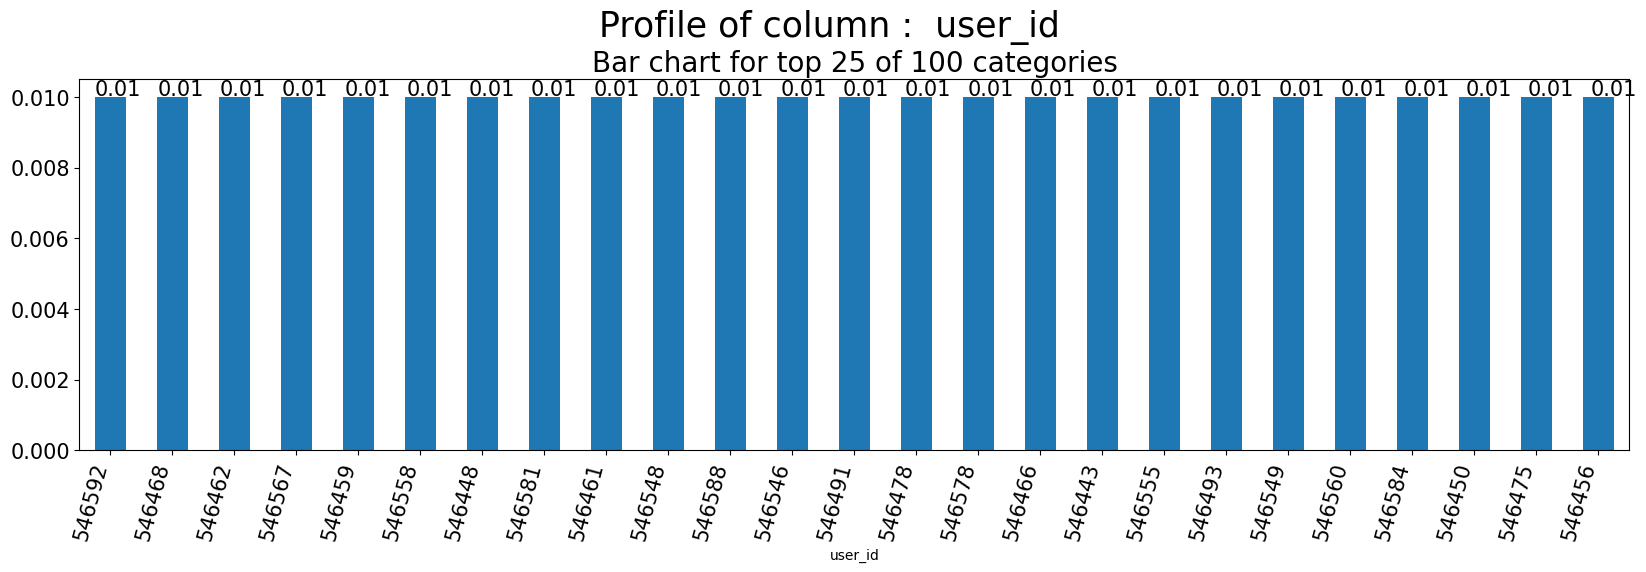

2  of  5  completed    group
fig_group


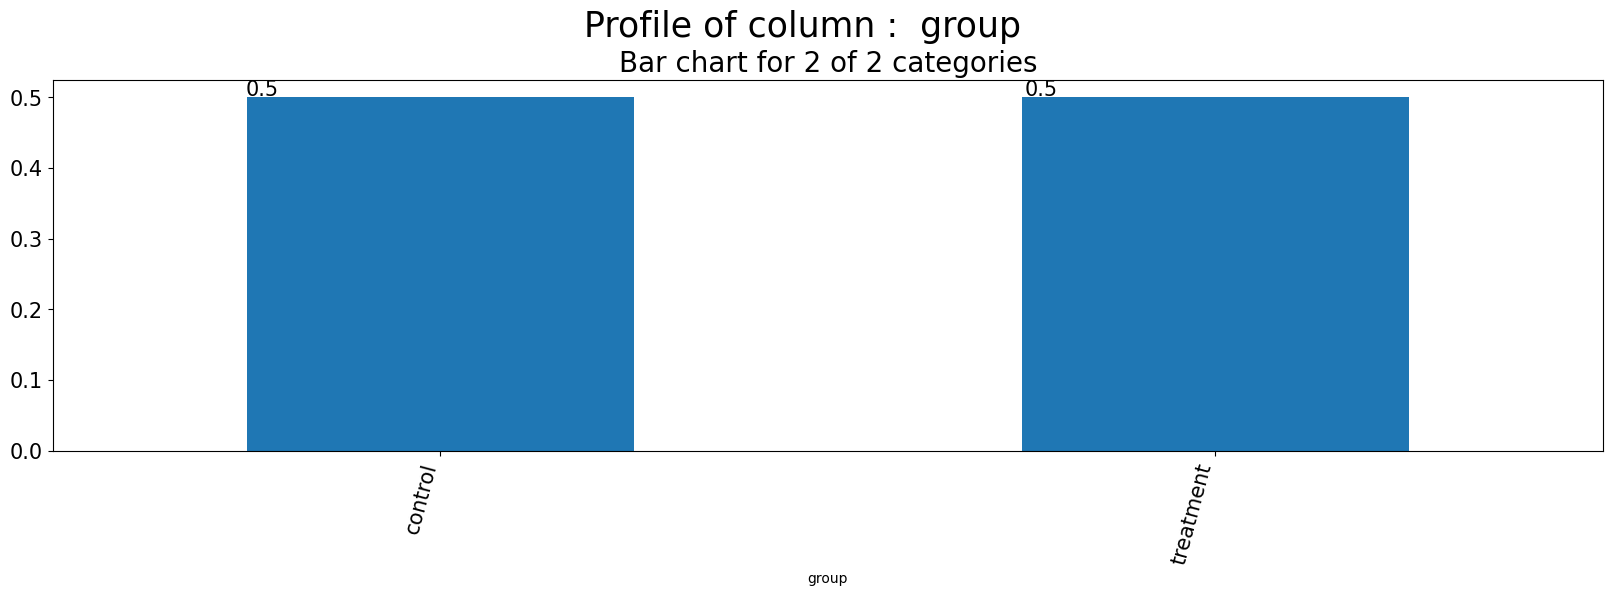

3  of  5  completed    landing_page
fig_landing_page


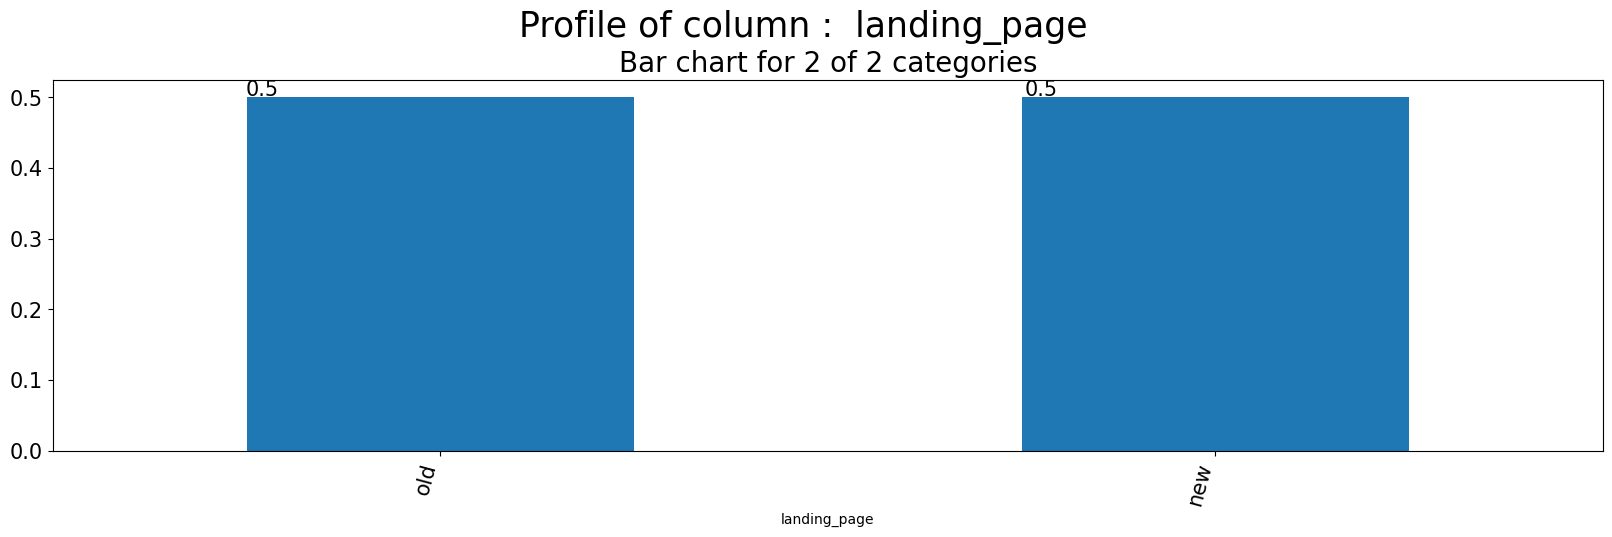

4  of  5  completed    converted
fig_converted


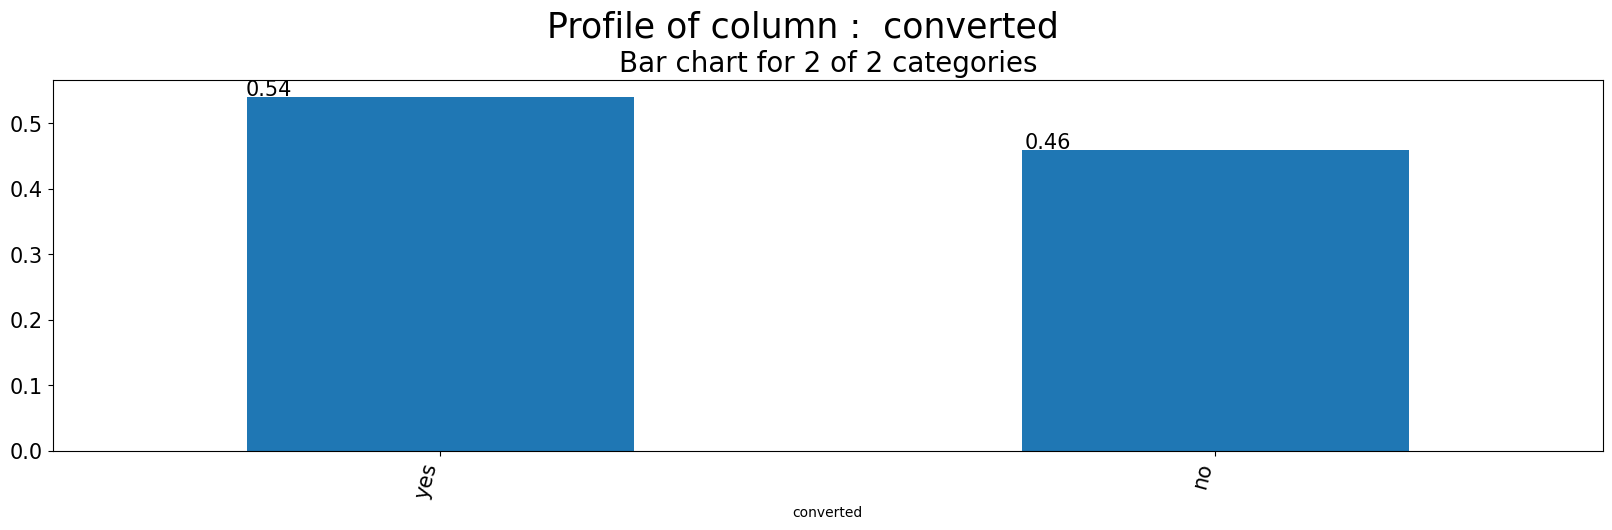

5  of  5  completed    language_preferred
fig_language_preferred


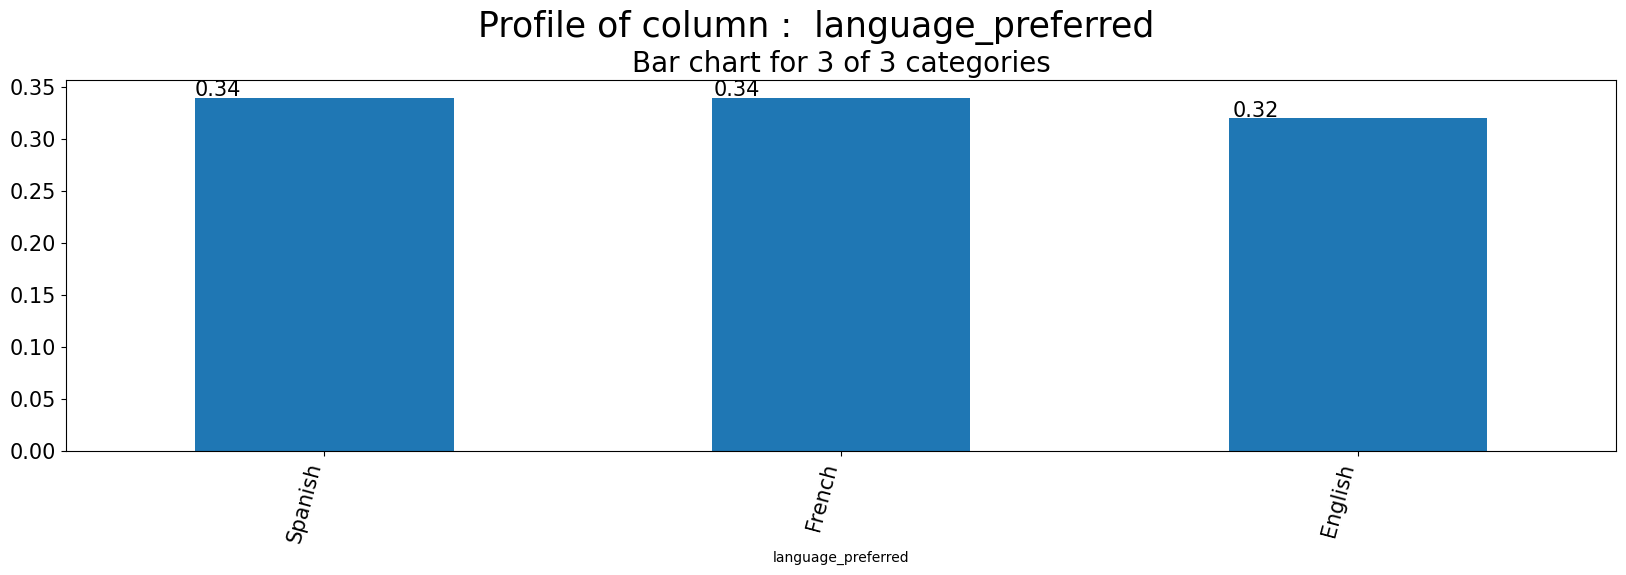

In [277]:
# Get the list of object columns from raw dataframe
# get object columns which are not empty


obj_cols = [cols for cols in df.columns if is_string_dtype(df[cols]) and len(df[cols].dropna())>0]


# print a report band (section ) as we loop through the columns
iter_len = len(obj_cols)


# For each object column in the list

for x, col_name in enumerate(obj_cols):
    # try:
        print(x+1, " of ", iter_len, " completed   ",  col_name)

        # Create a copy of the column values without nulls or NA
        column_in_play = df[col_name].dropna()

        values_freq_threshold = 25
        col_unique_count = df[col_name].nunique()
        col_count =  df[col_name].count()
        # If unique values count is below the threshold value then store the details of unique values
        col_unique_vals = df[col_name].value_counts(normalize=True, sort=True)

        # Plot the graphs
        fig2 = plt.figure(figsize=(20,7))
        fig2.suptitle("Profile of column  " + col_name, fontsize=25)  #Title for the whole figure
        plt.subplots_adjust(wspace=0.4, hspace=0.35, bottom=0.35)
        if col_unique_count > values_freq_threshold :
          myCaption ="Bar chart for top 25 of "  + str(col_unique_count) + " categories"
        else:
          myCaption = "Bar chart for " + str(col_unique_count) + " of "+ str( col_unique_count) + " categories"
        ax2 = fig2.add_subplot(1,1,1)
        ax2.set_title( myCaption, fontsize=20)
        plt.setp(ax2.get_xticklabels(), ha="right", rotation=45, fontsize=15)
        plt.setp(ax2.get_yticklabels(), ha="right", fontsize=15)

        col_unique_vals.head(values_freq_threshold).sort_values(ascending=False).plot.bar()
        plt.xticks(rotation=75)

        for p in ax2.patches:
            ax2.annotate(str(round(p.get_height(),2)), (p.get_x() * 1.005, p.get_height() * 1.005), fontsize=15)

        fig2.suptitle("Profile of column :  " + col_name, fontsize=25)  #Title for the whole figure

        from pathlib import Path
        fig_name = 'fig_' + col_name
        out_dir = Path("/content/drive/MyDrive/Colab Notebooks")
        fig_path = out_dir / fig_name
        print(fig_name)
        plt.show()
        fig2.savefig(fig_path , dpi= 50)


####Observatons
1. user_id - Unique user ID of the person visiting the website.
100 unique values and A uniform distribution

2. group - Whether the user belongs to the first group (control) or the second group (treatment). Two unique values 50/50 split.

3. landing_page - Whether the landing page is new or old. two unique values / 50/50 split and tracks with group.

4. time_spent_on_the_page - Time (in minutes) spent by the user on the landing page. A normal distribution.

5. converted - Whether the user gets converted to a subscriber of the news portal or not. values are yes (54) and no (46).

6. language_preferred - Language chosen by the user to view the landing page
three possible values ( Engilsh : 34, French 34 and Spanish 32.  

### Bivariate Analysis

         count   max  mean   min   sum
user_id                               
546443       1  8.73  8.73  8.73  8.73
546444       1  7.46  7.46  7.46  7.46
546445       1  7.27  7.27  7.27  7.27
546446       1  5.15  5.15  5.15  5.15
546447       1  3.30  3.30  3.30  3.30
...        ...   ...   ...   ...   ...
546588       1  6.21  6.21  6.21  6.21
546589       1  0.19  0.19  0.19  0.19
546590       1  5.47  5.47  5.47  5.47
546591       1  4.87  4.87  4.87  4.87
546592       1  3.48  3.48  3.48  3.48

[100 rows x 5 columns]


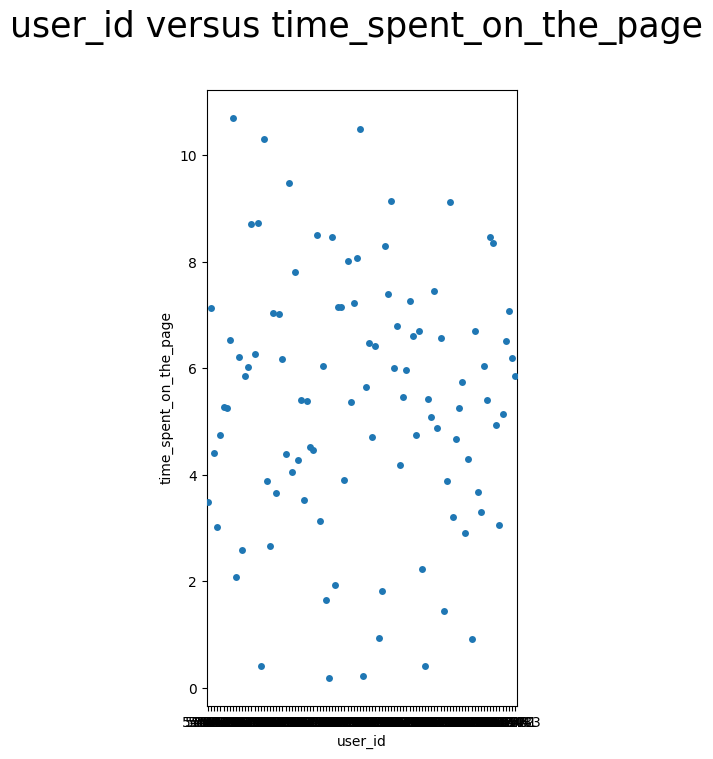

In [278]:
obj_name='user_id'
num_name='time_spent_on_the_page'
# Plot the graphs in a figure / frame
fig = plt.figure(figsize=(4,8))
fig.suptitle(  obj_name + " versus " + num_name, fontsize=25)  #Title for the whole figure
plt.subplots_adjust(wspace=0.4, hspace=0.35)
sns.stripplot(data=df,  x=obj_name, y=num_name );

p_table = df.pivot_table(
                        index=obj_name
                        , values=num_name
                        , aggfunc={num_name:['count','sum','mean','min','max']})
print (p_table)

           count    max    mean   min     sum
group                                        
control       50  10.30  4.5324  0.19  226.62
treatment     50  10.71  6.2232  1.65  311.16


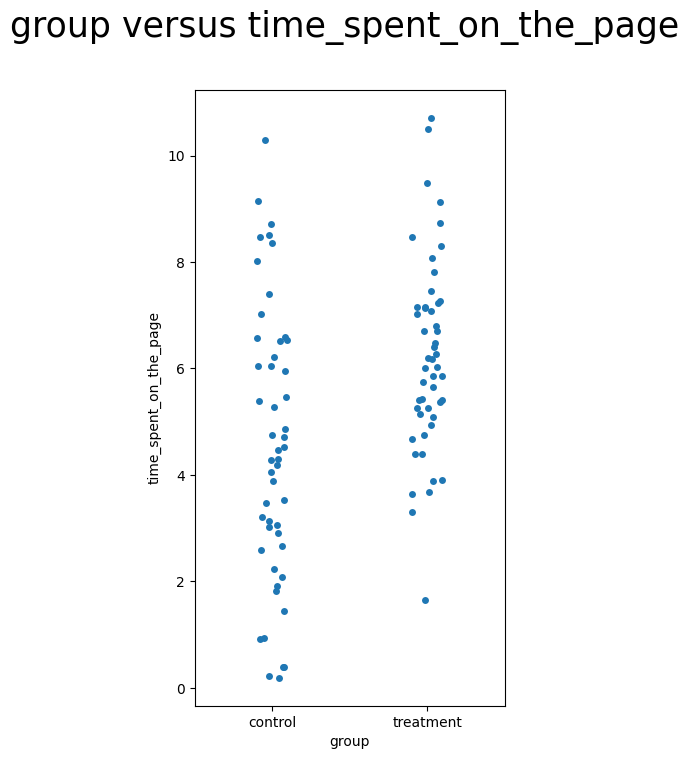

In [279]:
# Plot the graphs in a figure / frame
obj_name='group'
num_name='time_spent_on_the_page'
fig = plt.figure(figsize=(4,8))
fig.suptitle(  obj_name + " versus " + num_name, fontsize=25)  #Title for the whole figure
plt.subplots_adjust(wspace=0.4, hspace=0.35)
sns.stripplot(data=df,  x=obj_name, y=num_name );

p_table = df.pivot_table(
                        index=obj_name
                        , values=num_name
                        , aggfunc={num_name:['count','sum','mean','min','max']})
print (p_table)

           count    max    mean   min     sum
group                                        
control       50  10.30  4.5324  0.19  226.62
treatment     50  10.71  6.2232  1.65  311.16


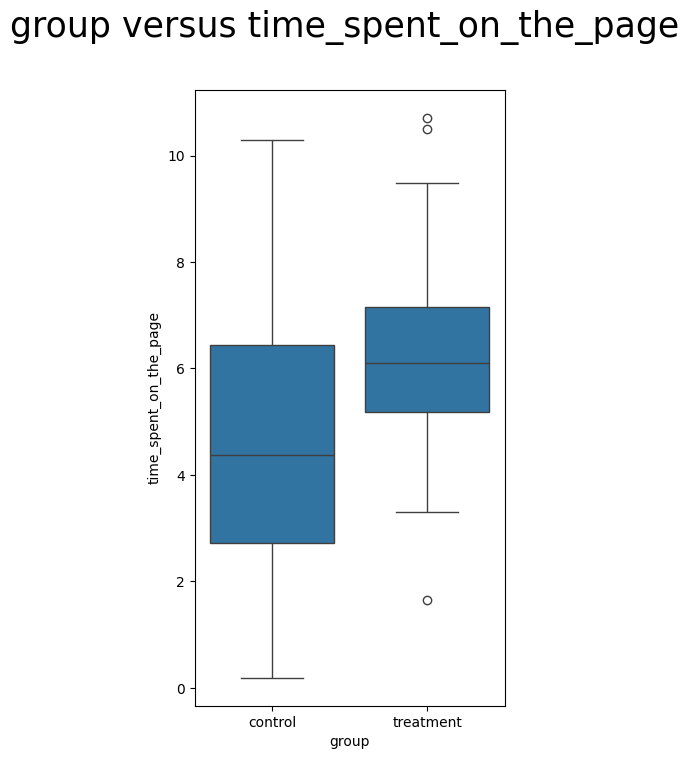

In [280]:
# Plot the graphs in a figure / frame
obj_name='group'
num_name='time_spent_on_the_page'
fig = plt.figure(figsize=(4,8))
fig.suptitle(  obj_name + " versus " + num_name, fontsize=25)  #Title for the whole figure
plt.subplots_adjust(wspace=0.4, hspace=0.35)
sns.boxplot(data=df,  x=obj_name, y=num_name );


p_table = df.pivot_table(
                        index=obj_name
                        , values=num_name
                        , aggfunc={num_name:['count','sum','mean','min','max']})
print (p_table)

              count    max    mean   min     sum
landing_page                                    
new              50  10.71  6.2232  1.65  311.16
old              50  10.30  4.5324  0.19  226.62


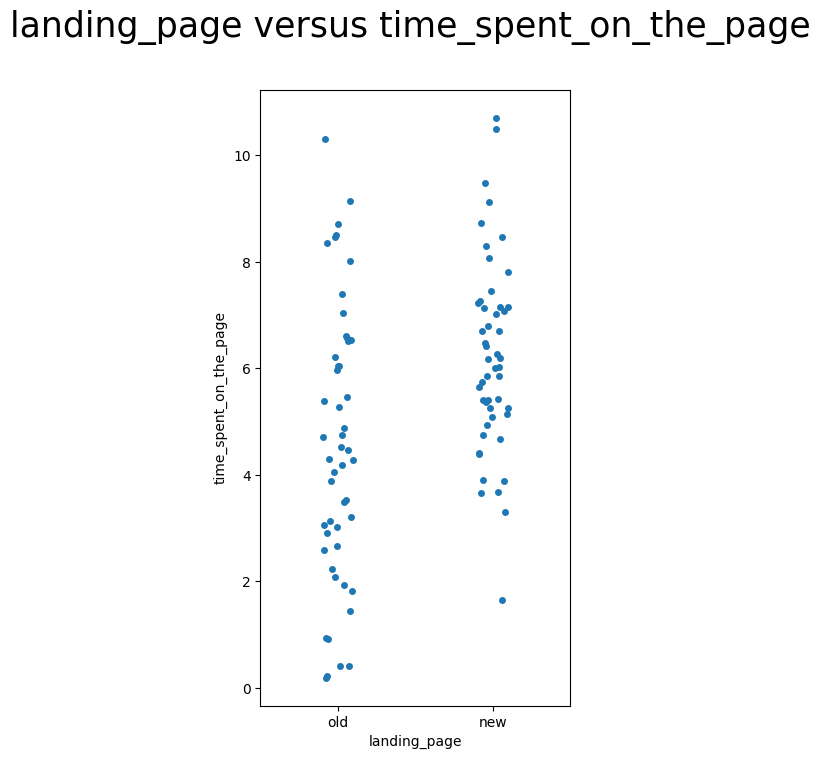

In [281]:
# Plot the graphs in a figure / frame
obj_name='landing_page'
num_name='time_spent_on_the_page'
fig = plt.figure(figsize=(4,8))
fig.suptitle(  obj_name + " versus " + num_name, fontsize=25)  #Title for the whole figure
plt.subplots_adjust(wspace=0.4, hspace=0.35)
sns.stripplot(data=df,  x=obj_name, y=num_name );

p_table = df.pivot_table(
                        index=obj_name
                        , values=num_name
                        , aggfunc={num_name:['count','sum','mean','min','max']})
print (p_table)

              count    max    mean   min     sum
landing_page                                    
new              50  10.71  6.2232  1.65  311.16
old              50  10.30  4.5324  0.19  226.62


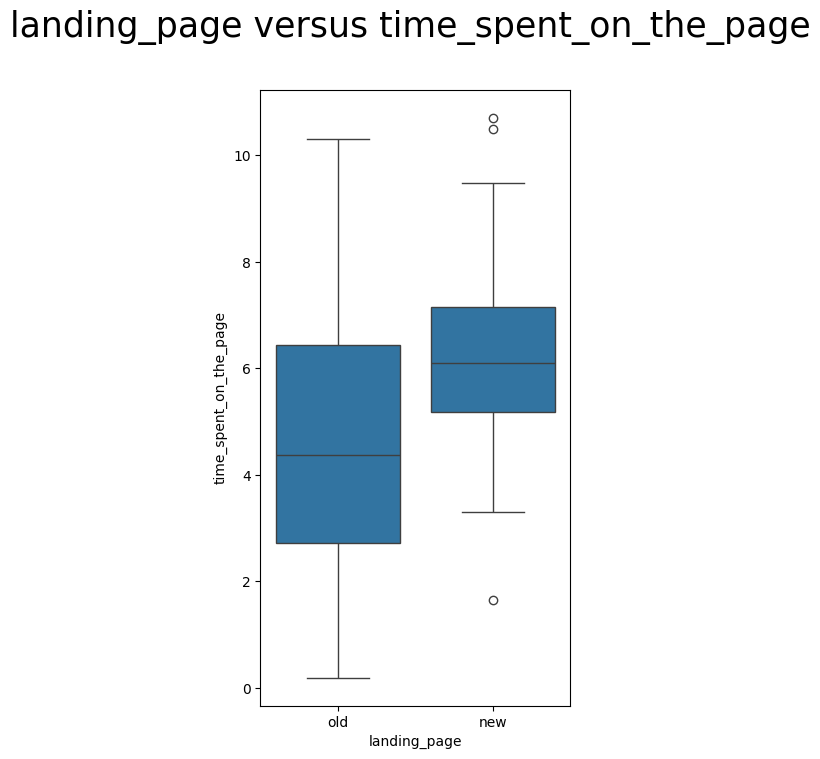

In [282]:
# Plot the graphs in a figure / frame
obj_name='landing_page'
num_name='time_spent_on_the_page'
fig = plt.figure(figsize=(4,8))
fig.suptitle(  obj_name + " versus " + num_name, fontsize=25)  #Title for the whole figure
plt.subplots_adjust(wspace=0.4, hspace=0.35)
sns.boxplot(data=df,  x=obj_name, y=num_name );

p_table = df.pivot_table(
                        index=obj_name
                        , values=num_name
                        , aggfunc={num_name:['count','sum','mean','min','max']})
print (p_table)

           count    max      mean   min     sum
converted                                      
no            46   9.15  3.915870  0.19  180.13
yes           54  10.71  6.623148  2.58  357.65


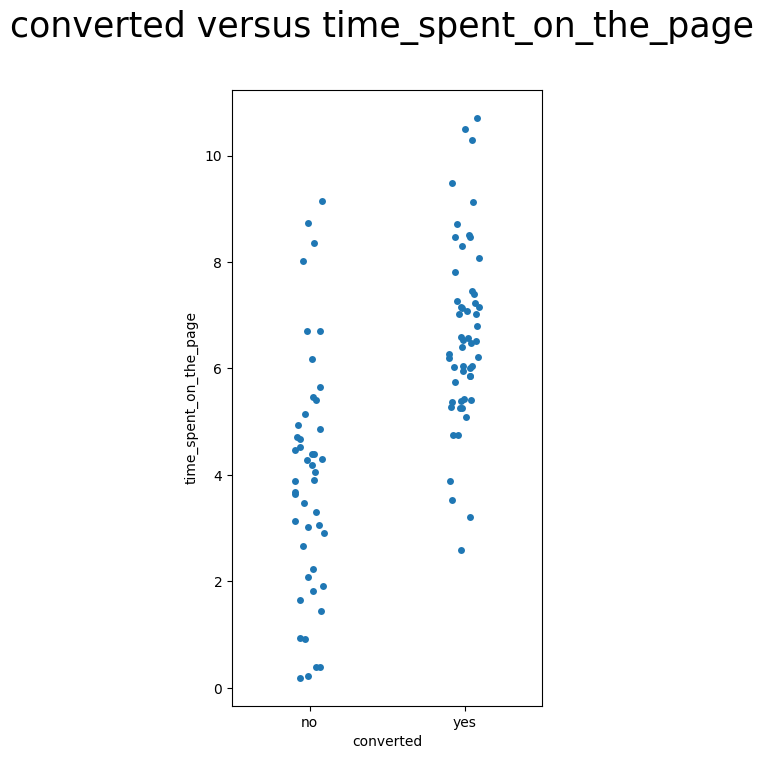

In [283]:
# Plot the graphs in a figure / frame
obj_name='converted'
num_name='time_spent_on_the_page'
fig = plt.figure(figsize=(4,8))
fig.suptitle(  obj_name + " versus " + num_name, fontsize=25)  #Title for the whole figure
plt.subplots_adjust(wspace=0.4, hspace=0.35)
sns.stripplot(data=df,  x=obj_name, y=num_name );

p_table = df.pivot_table(
                        index=obj_name
                        , values=num_name
                        , aggfunc={num_name:['count','sum','mean','min','max']})
print (p_table)

           count    max      mean   min     sum
converted                                      
no            46   9.15  3.915870  0.19  180.13
yes           54  10.71  6.623148  2.58  357.65


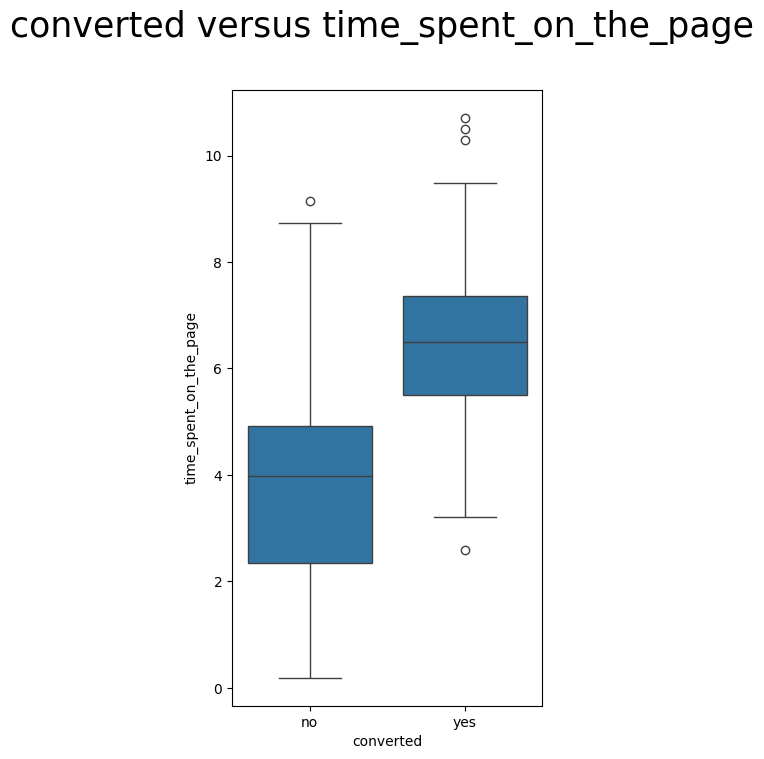

In [284]:
# Plot the graphs in a figure / frame
obj_name='converted'
num_name='time_spent_on_the_page'
fig = plt.figure(figsize=(4,8))
fig.suptitle(  obj_name + " versus " + num_name, fontsize=25)  #Title for the whole figure
plt.subplots_adjust(wspace=0.4, hspace=0.35)
sns.boxplot(data=df,  x=obj_name, y=num_name );

p_table = df.pivot_table(
                        index=obj_name
                        , values=num_name
                        , aggfunc={num_name:['count','sum','mean','min','max']})
print (p_table)

                    count    max      mean   min     sum
language_preferred                                      
English                32  10.50  5.559062  0.22  177.89
French                 34  10.71  5.253235  0.40  178.61
Spanish                34   8.72  5.331765  0.19  181.28


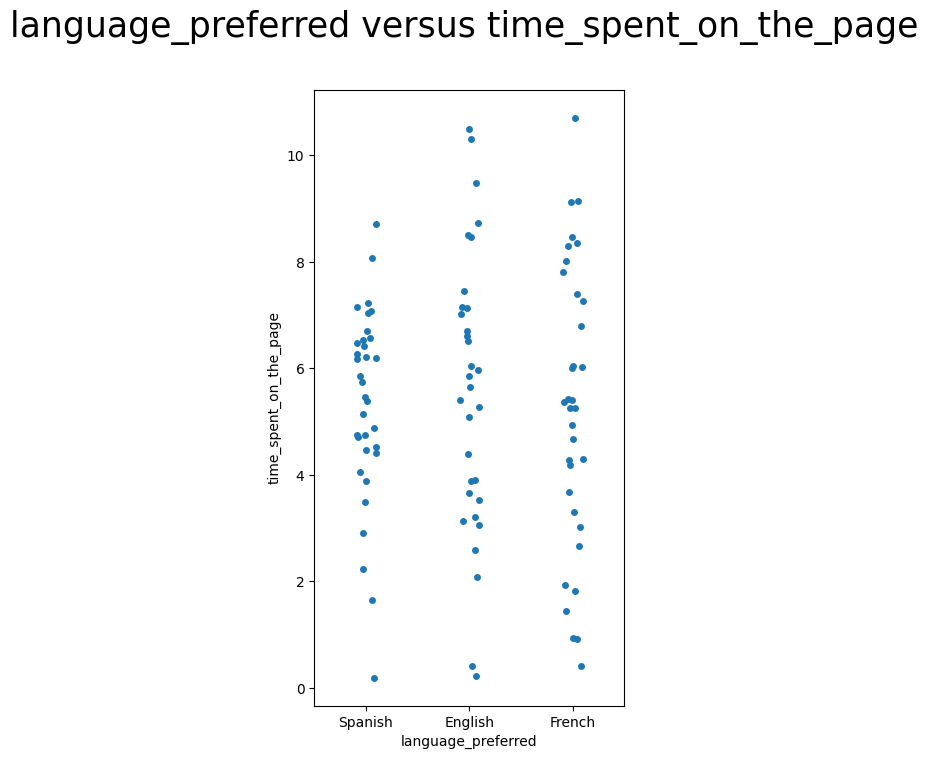

In [285]:
# Plot the graphs in a figure / frame
obj_name='language_preferred'
num_name='time_spent_on_the_page'
fig = plt.figure(figsize=(4,8))
fig.suptitle(  obj_name + " versus " + num_name, fontsize=25)  #Title for the whole figure
plt.subplots_adjust(wspace=0.4, hspace=0.35)
sns.stripplot(data=df,  x=obj_name, y=num_name );

p_table = df.pivot_table(
                        index=obj_name
                        , values=num_name
                        , aggfunc={num_name:['count','sum','mean','min','max']})
print (p_table)

                    count    max      mean   min     sum
language_preferred                                      
English                32  10.50  5.559062  0.22  177.89
French                 34  10.71  5.253235  0.40  178.61
Spanish                34   8.72  5.331765  0.19  181.28


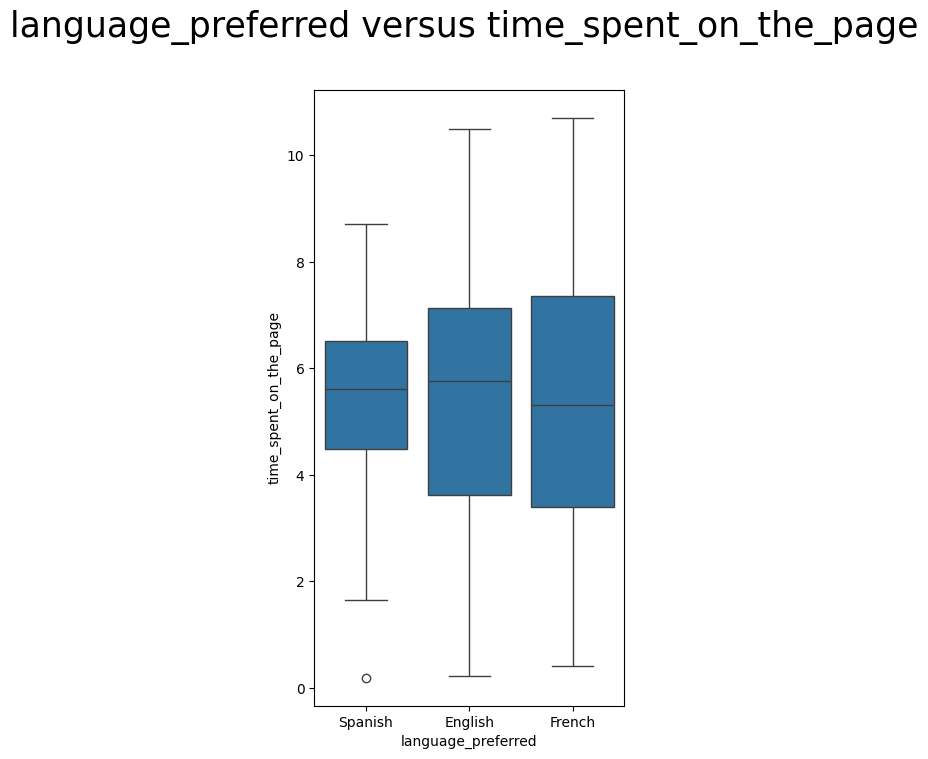

In [286]:
# Plot the graphs in a figure / frame
obj_name='language_preferred'
num_name='time_spent_on_the_page'
fig = plt.figure(figsize=(4,8))
fig.suptitle(  obj_name + " versus " + num_name, fontsize=25)  #Title for the whole figure
plt.subplots_adjust(wspace=0.4, hspace=0.35)
sns.boxplot(data=df,  x=obj_name, y=num_name );

p_table = df.pivot_table(
                        index=obj_name
                        , values=num_name
                        , aggfunc={num_name:['count','sum','mean','min','max']})
print (p_table)

#### Bivarate observations
1.  user_id - Unique user ID :No observations.

2. group - Treatment group has more mean minutes on a landing page. On average 1.7 minutes longers.

3. landing_page - Whether the landing page is new or old.new landing page  has more mean minutes on a landing page. On average 1.7 minutes longer

4. time_spent_on_the_page - Time (in minutes) spent by the user on the landing page. There appears to be a correlation between time spent on the landing and coversion. Longer times on the landing page yeirld more converstions.

5. converted - Whether the user gets converted to a subscriber of the news portal or not. Comments from number 4 apply here as well.

6. language_preferred - Language chosen by the user to view the landing page. Each language preference appaers to loiter on the page for approximately the same time.

## 1. Do the users spend more time on the new (treatment) landing page than the existing (control) landing page?

### Perform Visual Analysis

### Step 1: Define the null and alternate hypotheses

Let $\mu_1, \mu_2$ be the mean time on the **Treatment** (new)  and  the **Control** (existing) landing pages respectively.

*The null hypotheses*

>$H_0:\mu_1=\mu_2$

*The alternate hypothesis*

>$H_a:\mu_1>\mu_2$

### Step 2: Select Appropriate test

The test selected is the  **Independent (unpaired) two-sample t-test**

### Step 3: Decide the significance level

 The statistical analysis **significance level is 5%** per the project requirements.

### Step 4: Collect and prepare data

In [287]:
# This code is faulty... realized it rather late in the game...   time is short...

# A pivot table to verifiy my data collection is successful and gather some basic metrics
# obj_name='group'
# num_name='time_spent_on_the_page'
# p_table = df.pivot_table(
#                         index=obj_name
#                         , values=num_name
#                         , aggfunc={num_name:['count','sum','mean','min','max']})

# build A new frame of data limited to the columns in play

# control data
# options = ['control']
# df_left = df[['group','time_spent_on_the_page']]
# df_left =  df_left[df_left['group'].isin(options)]
# df_left= df_left.reset_index()
# # df_left['JoinKey'] =(df.index//2)+1
# df_left=df_left.rename({'time_spent_on_the_page':'control'}, axis='columns')
# df_left = df_left.drop('group', axis=1 )
# print(df_left.head())
# #treatment data
# options = ['treatment']
# df_right = df[['group','time_spent_on_the_page']]
# df_right =  df_right[df_right['group'].isin(options)]
# df_left= df_left.reset_index()
# df_right=df_right.rename({'time_spent_on_the_page':'treatment'}, axis='columns')
# df_right = df_right.drop('group', axis=1 )
# print(df_right.head())
# # merged data
# df_test1=pd.merge(df_left, df_right, left_index=True, right_index=True)
# df_test1.head()




In [288]:
landingpage.describe()

,control,treatment
count,50.000000,50.000000
mean,4.532400,6.223200
std,2.581975,1.817031
min,0.190000,1.650000
25%,2.720000,5.175000
50%,4.380000,6.105000
75%,6.442500,7.160000
max,10.300000,10.710000


In [289]:
# find the sample means and sample standard deviations for the two samples
print('The   mean  of time on landing page for    control group    is ' + str(landingpage['control'].mean()))
print('The   mean  of time on landing page for    treatment group  is ' + str(landingpage['treatment'].mean()))
print('The   standard deviation   of time on landing page for   control group   is ' + str(round(landingpage['control'].std(), 2)))
print('The   standard deviation   of time on landing page for   treatment group is ' + str(round(landingpage['treatment'].std(), 2)))


The   mean  of time on landing page for    control group    is 4.532400000000001
The   mean  of time on landing page for    treatment group  is 6.2232
The   standard deviation   of time on landing page for   control group   is 2.58
The   standard deviation   of time on landing page for   treatment group is 1.82


### are the T-test assumptions are satisfied or not

* Continuous data - Yes, the time is measured on a continuous scale.
* Normally distributed populations - Yes, we are informed that the populations are assumed to be normal.
* Independent populations - As we are taking random samples for two different groups, the two samples are from two independent populations.
* Unequal population standard deviations - As the sample standard deviations are different, the population standard deviations may be assumed to be different.
* Random sampling from the population - Yes, we are informed that the collected sample a simple random sample.

We can use two sample T-test for this problem.

### Step 5: Calculate the p-value

In [290]:
#import the required functions
from scipy.stats import ttest_ind

# find the p-value
test_stat, p_value = ttest_ind(
    landingpage['treatment'].dropna(),
    landingpage['control'].dropna(),
    equal_var=False,
    alternative='greater'
)
print('The p-value is', p_value)


The p-value is 0.0001392381225166549


### Step 6: Compare the p-value with $\alpha$

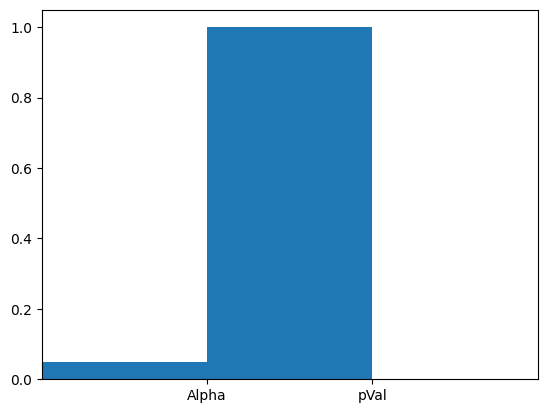

In [291]:
import matplotlib.pyplot as plt
import numpy as np

pVal = 0.000139
Alpha =.05
pVal > Alpha


BAR_WIDTH = 1.     # 0. < BAR_WIDTH <= 1.

# the data you want to plot
categories = ["Alpha", "pVal"]
values     = [ .05,  0.9998607618774834]
# x-values for the center of each bar
xs = np.arange(1, len(categories) + 1)
# plot each bar centered
plt.bar(xs - BAR_WIDTH/2, values, width=BAR_WIDTH)
# add bar labels
plt.xticks(xs, categories)
# make sure the chart is centered
plt.xlim(0, len(categories) + 1)
# show the results
plt.show()


### Step 7:  Draw inference

### Insight

The test is one-sided: mean time on the **new** page is greater than mean time on the **old** page.
If the p-value is less than 0.05, reject H0 and conclude users spend more time on the new page.
If the p-value is greater than 0.05, do not reject H0.

**A similar approach can be followed to answer the other questions.**

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

### Perform Visual Analysis

In [292]:
#pivot the main df to summarize (count) each group (control and treatment)
df_cr1= pd.pivot_table(df, index=['group'],columns='converted',  values='user_id', aggfunc=['count'], margins = True)

#drop the straddle header so I can treat the pivot as a df
df_cr1 = df_cr1.droplevel(0,axis=1).reset_index().rename_axis(columns=None)

# simple divsion to obtain conversion rates overall and by group
df_cr1['cRate'] = df_cr1["yes"]/df_cr1["All"]



df_cr1.head()

,group,no,yes,All,cRate
0,control,29,21,50,0.42
1,treatment,17,33,50,0.66
2,All,46,54,100,0.54


,group,cRate
0,control,0.42
1,treatment,0.66


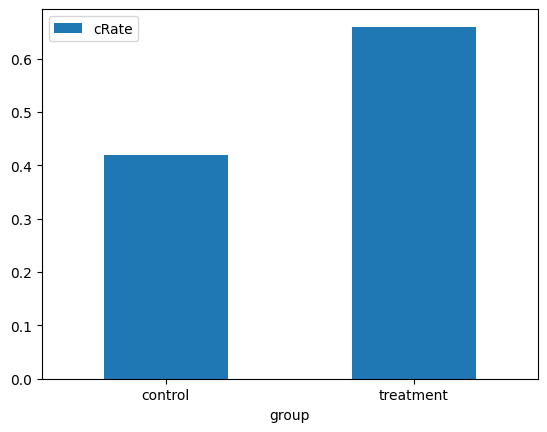

In [293]:
# focus the df on the group and the rate
df_cr1 = df_cr1[['group','cRate']]

# a list of target columns
options = ['control', 'treatment']

# selecting rows based on condition
df_cr1 = df_cr1[df_cr1['group'].isin(options)]
df_cr1.plot.bar(x='group', rot=0);

df_cr1.head()

### Draw inference
We calculate converstion rate on the new (treatment) landing page is 66% and the conversion rate for the existing landing page is 42%.  This is a net increase of 24% treatment old landing page (control)

 We conclude that the changes made to the treatment landing page provide a more engaging experience and is dramatically more effective at compelling using to convert.


## 3. Is the conversion and preferred language are independent or related?

### Perform Visual Analysis

,converted,English,French,Spanish
0,no,11,19,16
1,yes,21,15,18


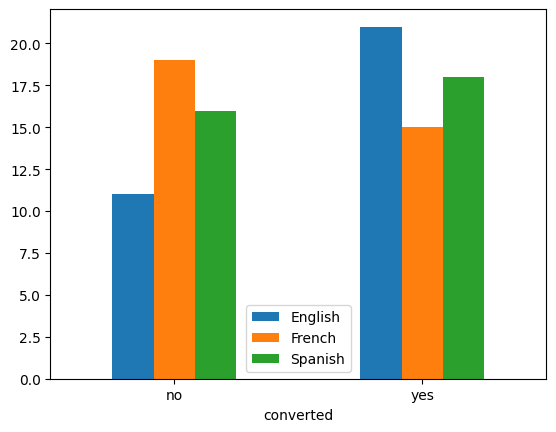

In [294]:
#pivot the main df to summarize (count) conversion success (no or yes) accross the categories of language
df_cr2= pd.pivot_table(df, index=['converted'],columns='language_preferred',  values='user_id', aggfunc=['count'])

#drop the straddle header so I can treat the pivot as a df
df_cr2 = df_cr2.droplevel(0,axis=1).reset_index().rename_axis(columns=None)

# plot the counts
df_cr2.plot.bar(x='converted', rot=0);

df_cr2.head()

### Step 1: Define the null and alternate hypotheses

*The null hypotheses*

>$H_0:$ language preference is indepent to conversion

*The alternate hypothesis*

>$H_a:$ conversion depends on language preference

### Step 2: Select Appropriate test
The test selected is the **Chi-Square Test for Independence**


### Step 3: Decide the significance level

 The statistical analysis **significance level is 5%** per the project requirements.

### Step 4: Collect and prepare data

### test that the assumptions are satisfied or not

* Categorical variables - Yes
* Expected value of the number of sample observations in each level of the variable is at least 5 - Yes, the number of observations in each level is greater than 5.
* Random sampling from the population - Yes, we are informed that the collected sample is a simple random sample.

In [295]:
df_cr2.head()

,converted,English,French,Spanish
0,no,11,19,16
1,yes,21,15,18


### Step 5: Calculate the p-value
The [`chi2_contingency()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html) function of Scipy will be used to compute the test statistic and p-value.

In [296]:
# import the required function
from scipy.stats import chi2_contingency

# find the p-value
chi, p_value, dof, expected = chi2_contingency(df_cr2.drop('converted', axis = 1))
print('The p-value is', p_value)

The p-value is 0.21298887487543447


### Step 6: Compare the p-value with $\alpha$

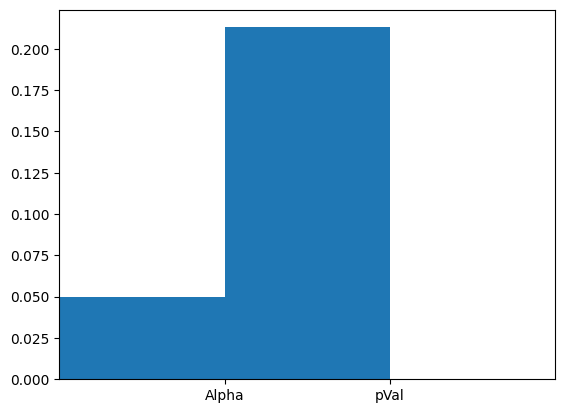

In [297]:
import matplotlib.pyplot as plt
import numpy as np

pVal = 0.21298887487543447
Alpha =.05
pVal > Alpha


BAR_WIDTH = 1.     # 0. < BAR_WIDTH <= 1.

# the data you want to plot
categories = ["Alpha", "pVal"]
values     = [ .05,  0.21298887487543447]
# x-values for the center of each bar
xs = np.arange(1, len(categories) + 1)
# plot each bar centered
plt.bar(xs - BAR_WIDTH/2, values, width=BAR_WIDTH)
# add bar labels
plt.xticks(xs, categories)
# make sure the chart is centered
plt.xlim(0, len(categories) + 1)
# show the results
plt.show()

### Step 7:  Draw inference

### Insight
As the p-value is much greater than the significance level and we cannot reject the null hypothesis. We do have enough statistical significance to conclude that conversion depends language preference.


## 4. Is the time spent on the new page same for the different language users?

### Perform Visual Analysis

In [298]:
dflook(df)

shape...
100 rows and 7 columns
head...


,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred,quartiles
0,546592,control,old,3.48,no,Spanish,"(0.189, 3.88]"
1,546468,treatment,new,7.13,yes,English,"(7.022, 10.71]"
2,546462,treatment,new,4.40,no,Spanish,"(3.88, 5.415]"
3,546567,control,old,3.02,no,French,"(0.189, 3.88]"
4,546459,treatment,new,4.75,yes,Spanish,"(3.88, 5.415]"


sample...


,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred,quartiles
22,546450,treatment,new,3.65,no,English,"(0.189, 3.88]"
15,546466,treatment,new,6.27,yes,Spanish,"(5.415, 7.022]"
94,546550,control,old,3.05,no,English,"(0.189, 3.88]"
53,546576,control,old,4.71,no,Spanish,"(3.88, 5.415]"
95,546446,treatment,new,5.15,no,Spanish,"(3.88, 5.415]"


tail...


,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred,quartiles
95,546446,treatment,new,5.15,no,Spanish,"(3.88, 5.415]"
96,546544,control,old,6.52,yes,English,"(5.415, 7.022]"
97,546472,treatment,new,7.07,yes,Spanish,"(7.022, 10.71]"
98,546481,treatment,new,6.20,yes,Spanish,"(5.415, 7.022]"
99,546483,treatment,new,5.86,yes,English,"(5.415, 7.022]"


  language_preferred  count    max      mean   min       std     sum
0            English     16  10.50  6.663750  3.65  1.984150  106.62
1             French     17  10.71  6.196471  3.30  1.933394  105.34
2            Spanish     17   8.08  5.835294  1.65  1.525656   99.20


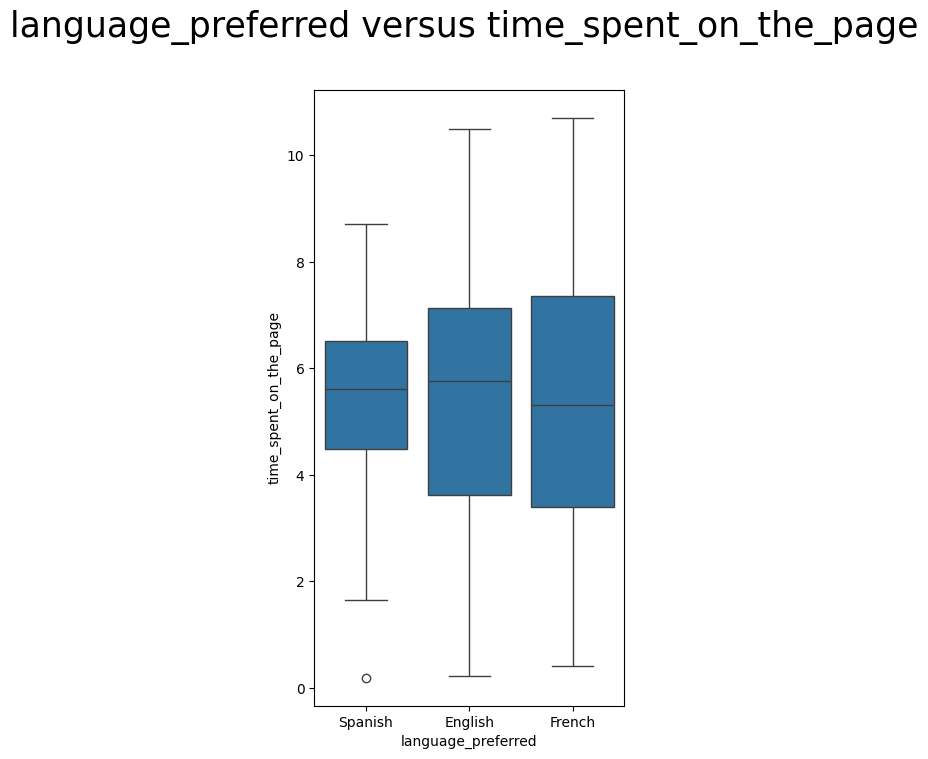

In [299]:
# pick the columns in play
obj_name='language_preferred'
num_name='time_spent_on_the_page'
tmp_df = df[['landing_page','language_preferred','time_spent_on_the_page']]

# prepare to filter for treatment records (new)
options = ['new']

#apply the filter keeping new landing page records
tmp_df =tmp_df[tmp_df['landing_page'].isin(options)]


#make a pivot to verify
p_table = tmp_df.pivot_table(
                        index=obj_name
                        , values=num_name
                        , aggfunc={num_name:['count','sum','mean','min','max','std']}).reset_index().rename_axis(columns=None)
print (p_table)

fig = plt.figure(figsize=(4,8))
fig.suptitle(  obj_name + " versus " + num_name, fontsize=25)  #Title for the whole figure
plt.subplots_adjust(wspace=0.4, hspace=0.35)
sns.boxplot(data=df,  x=obj_name, y=num_name  );

### Step 1: Define the null and alternate hypotheses
### Let's write the null and alternative hypothesis

Let $\mu_1, \mu_2, \mu_3$ be the means of users on the new page with the language preferences of English, French and Spanish respectively.

We will test the null hypothesis

>$H_0: \mu_1 = \mu_2 = \mu_3$

against the alternative hypothesis

>$H_a: $ At least one language preference on the new page is different from the rest.

### Step 2: Select Appropriate test
The seleted test is **One-way ANOVA Test**

### Step 3: Decide the significance level
 The statistical analysis **significance level is 5%** per the project requirements.

### Step 4: Collect and prepare data

In [300]:
dflook(tmp_df)

shape...
50 rows and 3 columns
head...


,landing_page,language_preferred,time_spent_on_the_page
1,new,English,7.13
2,new,Spanish,4.40
4,new,Spanish,4.75
6,new,French,5.25
8,new,French,10.71


sample...


,landing_page,language_preferred,time_spent_on_the_page
24,new,Spanish,6.18
81,new,French,5.26
81,new,French,5.26
52,new,Spanish,6.47
52,new,Spanish,6.47


tail...


,landing_page,language_preferred,time_spent_on_the_page
93,new,French,4.94
95,new,Spanish,5.15
97,new,Spanish,7.07
98,new,Spanish,6.20
99,new,English,5.86


language_preferred
English    6.663750
French     6.196471
Spanish    5.835294
Name: time_spent_on_the_page, dtype: float64


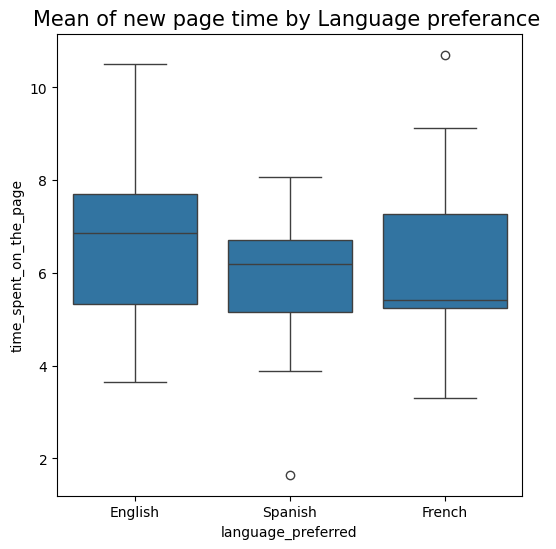

In [301]:
# mean of language preferance
print(tmp_df.groupby("language_preferred")["time_spent_on_the_page"].mean())

# draw the boxplot for visualization
fig, ax = plt.subplots(figsize = (6,6))
a = sns.boxplot(x= "language_preferred", y = 'time_spent_on_the_page' , data = tmp_df, )
a.set_title("Mean of new page time by Language preferance ", fontsize=15)
plt.show()

### Shapiro-Wilk’s test

We will test the null hypothesis

>$H_0:$ new page time follows a normal distribution against

against the alternative hypothesis

>$H_a:$ new page time does not follow a normal distribution

The shapiro() function of Scipy will be used to compute the test statistic and p-value.

In [302]:
# Assumption 1: Normality
# import the required function
from scipy import stats

# find the p-value
w, p_value = stats.shapiro(tmp_df['time_spent_on_the_page'])
print('The p-value is', p_value)

The p-value is 0.8040040364746845


Since p-value of the test is very large, we fail to reject the null hypothesis that the response follows the normal distribution.

### Levene’s test

We will test the null hypothesis

>$H_0$: All the population variances are equal

against the alternative hypothesis

>$H_a$: At least one variance is different from the rest

The levene() function of Scipy will be used to compute the test statistic and p-value.

In [303]:
#Assumption 2: Homogeneity of Variance
#import the required function
from scipy.stats import levene
statistic, p_value = levene( tmp_df['time_spent_on_the_page'][tmp_df['language_preferred']=="English"],
                                   tmp_df['time_spent_on_the_page'][tmp_df['language_preferred']=="French"],
                                   tmp_df['time_spent_on_the_page'][tmp_df['language_preferred']=="Spanish"])
# find the p-value
print('The p-value is', p_value)

The p-value is 0.46711357711340173


Since the p-value is large, we fail to reject the null hypothesis of homogeneity of variances.

### Step 5: Calculate the p-value

The f_oneway() function of Scipy will be used to compute the test statistic and p-value.

In [304]:
#import the required function
from scipy.stats import f_oneway

# perform one-way anova test
test_stat, p_value = f_oneway( tmp_df['time_spent_on_the_page'][tmp_df['language_preferred']=="English"],
                                   tmp_df['time_spent_on_the_page'][tmp_df['language_preferred']=="French"],
                                   tmp_df['time_spent_on_the_page'][tmp_df['language_preferred']=="Spanish"])
print('The p-value is ' + str(p_value))

The p-value is 0.43204138694325955


### Step 6: Compare the p-value with $\alpha$

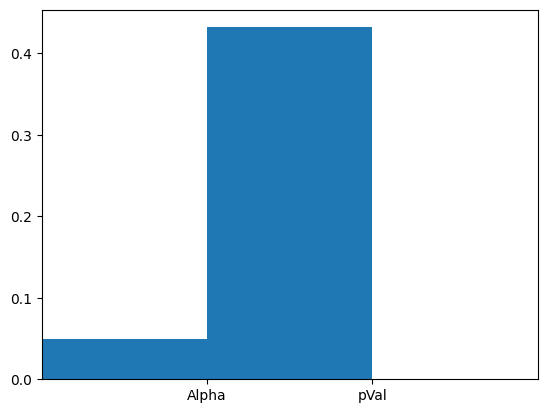

In [305]:
import matplotlib.pyplot as plt
import numpy as np

pVal = 0.43204138694325955
Alpha =.05
pVal > Alpha


BAR_WIDTH = 1.     # 0. < BAR_WIDTH <= 1.

# the data you want to plot
categories = ["Alpha", "pVal"]
values     = [ .05,  0.43204138694325955]
# x-values for the center of each bar
xs = np.arange(1, len(categories) + 1)
# plot each bar centered
plt.bar(xs - BAR_WIDTH/2, values, width=BAR_WIDTH)
# add bar labels
plt.xticks(xs, categories)
# make sure the chart is centered
plt.xlim(0, len(categories) + 1)
# show the results
plt.show()

### Insight

The p-value is greater than 0.05, so we do **not** reject H0.
That is not proof the three language groups spend identical time.
It is only this: at 5%, this sample does not show a language difference in time on the new page.

## Conclusion and Business Recommendations
1. Preliminry findings indicate success and the new landing page is infact driving conversion traffic to the news site. On average user spend 6.6 average minutes on the new site up from 4.7 minutes on the old.

2. The new page has a conversion rate of 66% while the old page has a conversion rate of 42%. this is 24 point lift.

3. Preferred Language has minimal impact on conversion

4. There is no statistical evidence that preferred language influences time on landing page.

Recommendations.
1. Make the new landing page customer facing. Use a phased approach to move to the new landing page.

2. Consider surveying and requesting feedback from customers.

3. Keep α = 0.05 unless the business sets a different risk.